## Part B (a): Two-Layer Perceptron Implemented from Scratch

Implement a feed-forward neural network with two hidden layers using only NumPy (or basic tensor operations). You are not allowed to use any automatic differentiation libraries.
Your model must satisfy the following constraints:
- Explicitly implement:
        - Forward propagation
        - Cross-entropy loss computation
        - Backward propagation using the algorithms and notations discussed in class
- First use
    (a) Sigmoid activation function, and then
    (b) ReLU activation function for
all hidden layers; and briefly explain how gradient properties influence optimization and gradient flow.
- Train the network using vanilla batch gradient descent for at least 200 iterations for both types of activation functions.
- Report the final training and validation accuracy values for both activation functions and present a single plot showing the variation of training and validation accuracy as a function of the iterations

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [244]:
train_df = pd.read_csv("../data/preprocessed/train.csv")
val_df = pd.read_csv("../data/preprocessed/validation.csv")


In [246]:
# Features only
X_train_df = train_df.drop(columns=['price_class']).copy()
X_val_df   = val_df.drop(columns=['price_class']).copy()

# Convert True/False -> 0/1
X_train_df = X_train_df.astype(np.float64)
X_val_df   = X_val_df.astype(np.float64)

# Now make arrays in your (features, m) shape
X_train = X_train_df.to_numpy().T
X_val   = X_val_df.to_numpy().T

# Labels
Y_train = train_df['price_class'].to_numpy(dtype=np.int64)
Y_val   = val_df['price_class'].to_numpy(dtype=np.int64)

print("X_train:", X_train.dtype, X_train.shape)
print("X_val  :", X_val.dtype, X_val.shape)

X_train: float64 (12, 33078)
X_val  : float64 (12, 8270)


In [247]:
INPUT_SIZE = X_train.shape[0]
HL1 = 32
HL2 = 16
OUTPUT_SIZE = len(np.unique(Y_train))


In [250]:
# initializing parameters
def init_params():
    # size of weight matric is M^(l) x M^(l-1) where M = no of neurons
    # size of bias is M^l
    W1 = np.random.randn(HL1, INPUT_SIZE) * 0.01
    b1 = np.zeros((HL1, 1))

    W2 = np.random.randn(HL2, HL1) * 0.01
    b2 = np.zeros((HL2, 1))

    W3 = np.random.randn(OUTPUT_SIZE, HL2) * 0.01
    b3 = np.zeros((OUTPUT_SIZE, 1))

    return W1, b1, W2, b2, W3, b3

In [251]:
def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

def ReLU(Z):
  return np.maximum(Z, 0)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # stability
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def sigmoid_derivative(A):
    return A * (1 - A)


def ReLU_derivative(Z):
    return (Z > 0).astype(np.float64)

In [252]:
def activation_forward(Z, activation):
    if activation == "relu":
        return ReLU(Z)
    elif activation == "sigmoid":
        return sigmoid(Z)
    else:
        raise ValueError("activation must be 'relu' or 'sigmoid'")

def activation_backward(Z, activation):
    if activation == "relu":
        return ReLU_derivative(Z)
    elif activation == "sigmoid":
        A = sigmoid(Z)          # derivative needs sigmoid output
        return A * (1 - A)
    else:
        raise ValueError("activation must be 'relu' or 'sigmoid'")

In [253]:
def forward_propagation(X, W1, b1, W2, b2, W3, b3, activation="relu"):
    Z1 = W1 @ X + b1
    A1 = activation_forward(Z1, activation)

    Z2 = W2 @ A1 + b2
    A2 = activation_forward(Z2, activation)

    Z3 = W3 @ A2 + b3
    Y_hat = softmax(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, Y_hat)
    return Y_hat, cache

In [254]:
def one_hot_encoder(Y):
  one_hot_encoder = np.zeros((Y.size, Y.max() + 1))
  one_hot_encoder[np.arange(Y.size), Y] = 1
  return one_hot_encoder.T

In [255]:
def cross_entropy_loss(Y_hat, Y_onehot):
    # Y_hat: (C, m), Y_onehot: (C, m)
    m = Y_onehot.shape[1]
    eps = 1e-12
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    loss = -np.sum(Y_onehot * np.log(Y_hat)) / m
    return loss

In [256]:
def cross_entropy_loss_weighted(Y_hat, Y_onehot, class_weights):
    m = Y_onehot.shape[1]
    eps = 1e-12
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return -np.sum(class_weights * Y_onehot * np.log(Y_hat)) / m

In [257]:
def backward_propagation(cache, Y_onehot, W2, W3, activation="relu", class_weights=None):
    X, Z1, A1, Z2, A2, Z3, Y_hat = cache
    m = X.shape[1]

    # Softmax + Cross-Entropy
    dZ3 = (Y_hat - Y_onehot)  # (C, m)

    # Apply class weights ONLY if provided (sigmoid case)
    if class_weights is not None:
        # class_weights: (C, 1) -> broadcasts over (C, m)
        dZ3 = dZ3 * class_weights

    dW3 = (dZ3 @ A2.T) / m
    db3 = np.sum(dZ3, axis=1, keepdims=True) / m

    # Layer 2
    dA2 = W3.T @ dZ3
    dZ2 = dA2 * activation_backward(Z2, activation)
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # Layer 1
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * activation_backward(Z1, activation)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

In [258]:
def update_params(W1, b1, W2, b2, W3, b3, grads, lr):
    dW1, db1, dW2, db2, dW3, db3 = grads

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3

    return W1, b1, W2, b2, W3, b3

In [259]:
def predict(X, W1, b1, W2, b2, W3, b3, activation="relu"):
    Y_hat, _ = forward_propagation(X, W1, b1, W2, b2, W3, b3, activation)
    return np.argmax(Y_hat, axis=0)

In [311]:
def accuracy(y_pred, y_true):
    return np.mean(y_pred == y_true)

In [261]:
def train_model(X_train, Y_train, X_val, Y_val, *, epochs, lr, print_every, activation="relu"):
    W1, b1, W2, b2, W3, b3 = init_params()

    # Xavier-like rescale ONLY for sigmoid (since init_params uses *0.01)
    if activation == "sigmoid":
        W1 *= (np.sqrt(1 / INPUT_SIZE) / 0.01)
        W2 *= (np.sqrt(1 / HL1)        / 0.01)
        W3 *= (np.sqrt(1 / HL2)        / 0.01)

    Y_train_oh = one_hot_encoder(Y_train)

    # Class weights ONLY for sigmoid
    if activation == "sigmoid":
        counts = np.bincount(Y_train, minlength=OUTPUT_SIZE)
        class_weights = (counts.sum() / (OUTPUT_SIZE * counts)).reshape(-1, 1)
    else:
        class_weights = None

    train_acc_history = []
    val_acc_history = []
    gW1_history = []
    gW2_history = []

    for epoch in range(1, epochs + 1):
        # forward
        Y_hat, cache = forward_propagation(X_train, W1, b1, W2, b2, W3, b3, activation)

        # loss (weighted only for sigmoid)
        if class_weights is None:
            loss = cross_entropy_loss(Y_hat, Y_train_oh)
        else:
            loss = cross_entropy_loss_weighted(Y_hat, Y_train_oh, class_weights)

        # backward (weighted only for sigmoid)
        grads = backward_propagation(cache, Y_train_oh, W2, W3, activation, class_weights)
        dW1, db1, dW2, db2, dW3, db3 = grads

        # gradient magnitude histories (Part B(b))
        gW1_history.append(np.mean(np.abs(dW1)))
        gW2_history.append(np.mean(np.abs(dW2)))

        # update
        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, grads, lr)

        # accuracy
        train_pred = predict(X_train, W1, b1, W2, b2, W3, b3, activation)
        val_pred   = predict(X_val,   W1, b1, W2, b2, W3, b3, activation)

        train_acc = accuracy(train_pred, Y_train)
        val_acc   = accuracy(val_pred,   Y_val)

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        if epoch % print_every == 0 or epoch == 1:
            print(f"{activation} | Epoch {epoch:4d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return W1, b1, W2, b2, W3, b3, train_acc_history, val_acc_history, gW1_history, gW2_history

In [262]:
# Define hyperparameters
EPOCHS = 600
LEARNING_RATE = 0.2
ACTIVATION = "sigmoid"

W1, b1, W2, b2, W3, b3, sig_train, sig_val, sig_gW1, sig_gW2 = train_model(
    X_train,
    Y_train,
    X_val,
    Y_val,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    print_every=20,
    activation=ACTIVATION)



sigmoid | Epoch    1 | Loss: 1.5619 | Train Acc: 0.2391 | Val Acc: 0.2341
sigmoid | Epoch   20 | Loss: 1.6693 | Train Acc: 0.5618 | Val Acc: 0.5688
sigmoid | Epoch   40 | Loss: 1.6440 | Train Acc: 0.5618 | Val Acc: 0.5688
sigmoid | Epoch   60 | Loss: 1.6047 | Train Acc: 0.5618 | Val Acc: 0.5688
sigmoid | Epoch   80 | Loss: 1.5382 | Train Acc: 0.5618 | Val Acc: 0.5688
sigmoid | Epoch  100 | Loss: 1.4270 | Train Acc: 0.5720 | Val Acc: 0.5781
sigmoid | Epoch  120 | Loss: 1.2700 | Train Acc: 0.6411 | Val Acc: 0.6493
sigmoid | Epoch  140 | Loss: 1.1086 | Train Acc: 0.6932 | Val Acc: 0.6988
sigmoid | Epoch  160 | Loss: 0.9849 | Train Acc: 0.7087 | Val Acc: 0.7131
sigmoid | Epoch  180 | Loss: 0.9001 | Train Acc: 0.7140 | Val Acc: 0.7189
sigmoid | Epoch  200 | Loss: 0.8408 | Train Acc: 0.7158 | Val Acc: 0.7207
sigmoid | Epoch  220 | Loss: 0.7970 | Train Acc: 0.7429 | Val Acc: 0.7475
sigmoid | Epoch  240 | Loss: 0.7629 | Train Acc: 0.7621 | Val Acc: 0.7649
sigmoid | Epoch  260 | Loss: 0.7354 | 

In [263]:
EPOCHS = 600
LEARNING_RATE = 0.4
ACTIVATION = "relu"

W1, b1, W2, b2, W3, b3, relu_train, relu_val, relu_gW1, relu_gW2 = train_model(
    X_train,
    Y_train,
    X_val,
    Y_val,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    print_every=20,
    activation=ACTIVATION)

relu | Epoch    1 | Loss: 1.3863 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch   20 | Loss: 1.1228 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch   40 | Loss: 1.1145 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch   60 | Loss: 1.1132 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch   80 | Loss: 1.1129 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  100 | Loss: 1.1128 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  120 | Loss: 1.1128 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  140 | Loss: 1.1128 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  160 | Loss: 1.1127 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  180 | Loss: 1.1127 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  200 | Loss: 1.1126 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  220 | Loss: 1.1124 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  240 | Loss: 1.1119 | Train Acc: 0.5618 | Val Acc: 0.5688
relu | Epoch  260 | Loss: 1.1103 | Train Acc: 0.5618 | Val Acc: 0.5688
relu |

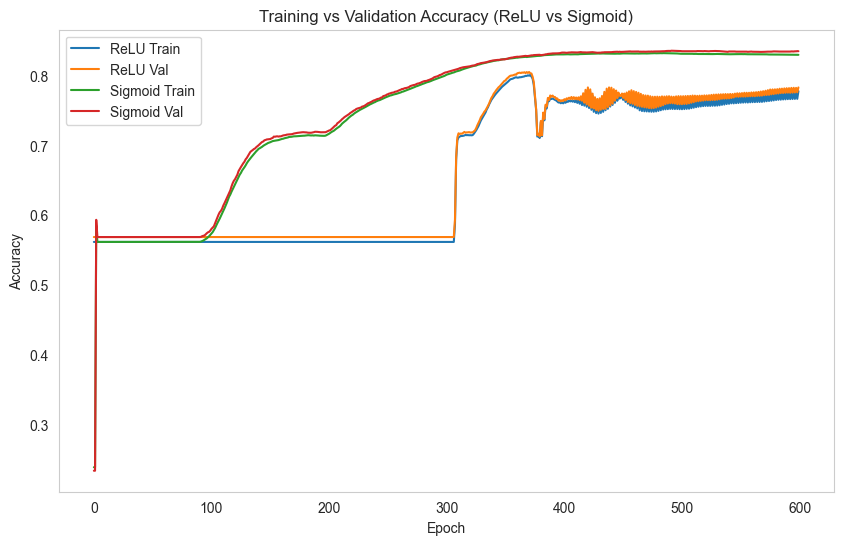

In [264]:
plt.figure(figsize=(10, 6))
plt.plot(relu_train, label="ReLU Train")
plt.plot(relu_val,   label="ReLU Val")
plt.plot(sig_train,  label="Sigmoid Train")
plt.plot(sig_val,    label="Sigmoid Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (ReLU vs Sigmoid)")
plt.legend()
plt.grid(False)
plt.show()

## Part B (b): Gradient Magnitude Comparison Across Layers

Using your trained networks (with both activation functions) from Part B (a), perform the following analysis:

- Compute the average magnitude of gradients for the first and second hidden layer weights and compare these gradient magnitudes quantitatively as a function of the iterations. Do this for both types of activation functions.
    - What do you observe? And what do your results reveal about gradient flow and learning dynamics in deep networks.

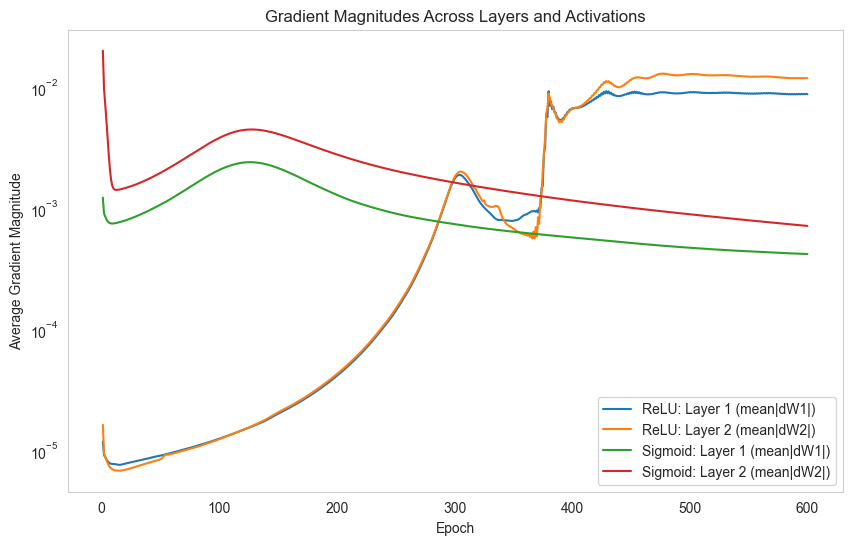

In [265]:
epochs = np.arange(1, len(relu_gW1) + 1)

plt.figure(figsize=(10, 6))
plt.yscale("log")

plt.plot(epochs, relu_gW1, label="ReLU: Layer 1 (mean|dW1|)")
plt.plot(epochs, relu_gW2, label="ReLU: Layer 2 (mean|dW2|)")

plt.plot(epochs, sig_gW1,  label="Sigmoid: Layer 1 (mean|dW1|)")
plt.plot(epochs, sig_gW2,  label="Sigmoid: Layer 2 (mean|dW2|)")

plt.xlabel("Epoch")
plt.ylabel("Average Gradient Magnitude")
plt.title("Gradient Magnitudes Across Layers and Activations")
plt.legend()
plt.grid(False)

plt.show()

In [266]:
relu_gW1 = np.array(relu_gW1)
relu_gW2 = np.array(relu_gW2)
sig_gW1  = np.array(sig_gW1)
sig_gW2  = np.array(sig_gW2)

print("===== ReLU =====")
print("Layer 1 mean:", relu_gW1.mean())
print("Layer 2 mean:", relu_gW2.mean())


print("\n===== Sigmoid =====")
print("Layer 1 mean:", sig_gW1.mean())
print("Layer 2 mean:", sig_gW2.mean())


===== ReLU =====
Layer 1 mean: 0.0033654926168754733
Layer 2 mean: 0.004330864682757225

===== Sigmoid =====
Layer 1 mean: 0.0009568391146506583
Layer 2 mean: 0.0019576764791141513


## Part C (b): Implementation and Results

In this part, you may either re-train a
comparable two-hidden-layer MLP using PyTorch, or reuse the architecture from Part B and implement the required modifications. The architecture must remain comparable to the network used previously.
Go through Section 2.8 of Charu C. Aggarwal’s Textbook.
- Implement your proposed gradient-based feature attribution method explained in Section 2.8 of the textbook.
- Implement your ranked list of the most influential input features.
- Briefly interpret the results and relate them back to your findings from Part A.
- For your report submission, provide a pseudo-code of your version of the implemented
algorithm.

In [269]:
def forward_with_logits(X, W1, b1, W2, b2, W3, b3, activation="relu"):
    Z1 = W1 @ X + b1
    A1 = activation_forward(Z1, activation)

    Z2 = W2 @ A1 + b2
    A2 = activation_forward(Z2, activation)

    Z3 = W3 @ A2 + b3          # logits
    Y_hat = softmax(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, Y_hat)
    return Z3, Y_hat, cache

In [270]:
def input_gradient_winning_logit(cache, W1, W2, W3, activation, m_idx):
    """
    Returns grad_x = d o_m / d x for ONE sample.
    cache must be for ONE sample with shapes:
      X:  (d, 1)
      Z1: (HL1, 1), A1: (HL1, 1)
      Z2: (HL2, 1), A2: (HL2, 1)
      Z3: (K, 1)
    """
    X, Z1, A1, Z2, A2, Z3, Y_hat = cache

    K = Z3.shape[0]
    dZ3 = np.zeros((K, 1), dtype=np.float64)
    dZ3[m_idx, 0] = 1.0  # selects winning logit o_m

    # Backprop: z3 -> a2
    dA2 = W3.T @ dZ3                         # (HL2, 1)
    dZ2 = dA2 * activation_backward(Z2, activation)

    # z2 -> a1
    dA1 = W2.T @ dZ2                         # (HL1, 1)
    dZ1 = dA1 * activation_backward(Z1, activation)

    # z1 -> x
    grad_x = W1.T @ dZ1                      # (d, 1)

    return grad_x

In [271]:
def agg_feature_importance_aggarwal(
    X, Y,
    W1, b1, W2, b2, W3, b3,
    feature_names,
    activation="relu",
    only_correct=True,
    max_samples=None,       # set e.g. 5000 for faster debug; None = use all
    verbose=True
):
    """
    Computes Aggarwal-style importance:
      S_i = mean_n | d o_m(x^n) / d x_i |
    where m is the winning class for sample n.

    X: (d, m)
    Y: (m,)
    returns: scores (d,), ranked_df
    """
    d, m_total = X.shape
    assert len(feature_names) == d

    indices = np.arange(m_total)
    if max_samples is not None and max_samples < m_total:
        indices = np.random.choice(indices, size=max_samples, replace=False)

    S = np.zeros((d,), dtype=np.float64)
    used = 0

    for j in indices:
        xj = X[:, j:j+1]  # (d,1)
        yj = int(Y[j])

        Z3, Y_hat, cache = forward_with_logits(xj, W1, b1, W2, b2, W3, b3, activation=activation)

        pred = int(np.argmax(Z3, axis=0)[0])  # winning logit index
        if only_correct and pred != yj:
            continue

        grad_x = input_gradient_winning_logit(cache, W1, W2, W3, activation=activation, m_idx=pred)
        S += np.abs(grad_x[:, 0])
        used += 1

    if used == 0:
        raise ValueError("No samples aggregated. Try only_correct=False or check model accuracy.")

    scores = S / used

    ranked = pd.DataFrame({
        "feature": feature_names,
        "importance": scores
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    if verbose:
        print(f"Aggregated samples used: {used} / {len(indices)} (only_correct={only_correct})")
        print(ranked)

    return scores, ranked

In [272]:
feature_names = [
    'minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365',
    'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan',
    'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island',
    'neighbourhood_group_Unknown', 'room_type_Private room',
    'room_type_Shared room', 'room_type_Unknown'
]

scores, ranked_df = agg_feature_importance_aggarwal(
    X_train, Y_train,
    W1, b1, W2, b2, W3, b3,
    feature_names,
    activation="relu",      # or "sigmoid"
    only_correct=True,
    max_samples=None        # set to 5000 if you want faster first run
)

top10 = ranked_df.head(10)
top10

Aggregated samples used: 25728 / 33078 (only_correct=True)
                              feature  importance
0                       amenity_score    1.691301
1               room_type_Shared room    0.764747
2              room_type_Private room    0.530626
3       neighbourhood_group_Manhattan    0.383294
4        neighbourhood_group_Brooklyn    0.297768
5          neighbourhood_group_Queens    0.224729
6                   room_type_Unknown    0.180149
7                      minimum_nights    0.157892
8   neighbourhood_group_Staten Island    0.142119
9                    availability_365    0.081603
10        neighbourhood_group_Unknown    0.072583
11                  number_of_reviews    0.053056


,feature,importance
0,amenity_score,1.691301
1,room_type_Shared room,0.764747
2,room_type_Private room,0.530626
3,neighbourhood_group_Manhattan,0.383294
4,neighbourhood_group_Brooklyn,0.297768
5,neighbourhood_group_Queens,0.224729
6,room_type_Unknown,0.180149
7,minimum_nights,0.157892
8,neighbourhood_group_Staten Island,0.142119
9,availability_365,0.081603


## Part D: Test Evaluation and Generalization Analysis

Evaluate your trained PyTorch model on the provided test dataset and analyze its generalization behavior.
Your submission must include:
- The reported test accuracy.
- A comparison between training, validation, and test performance and evidence-based analysis explaining any observed performance gap.
- Identification of the root cause of generalization failure using:
    – Exploratory data analysis from Part A
    – Gradient-based feature attribution from Part C
- A clear explanation of why the model performs well during training but fails on the test set.
- Suggest a strategy that could mitigate this issue in practice, with brief justification.

In [343]:
test_df_raw = pd.read_csv("../data/preprocessed/test.csv")
train_df_raw = pd.read_csv("../data/raw/train.csv")

In [344]:
print("\n===== Categorical Variable Summary =====\n")
categorical_columns = train_df_raw.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Number of categorical columns: {len(categorical_columns)}\n")
for idx,col in enumerate(categorical_columns):
    unique_values = test_df_raw[col].dropna().unique()
    n_unique = len(unique_values)
    n_missing = test_df_raw[col].isna().sum()
    print(f"{idx+1}. {col}")
    print(f"Number of unique categories: {n_unique}")
    print(f"Missing values: {n_missing}")
    print("Categories:")

    for val in sorted(unique_values):
        print(f"  - {val}")
    print("\n")
print(f"Before encoding\n {test_df_raw.head()}")
test_df = pd.get_dummies(
    test_df_raw,
    columns=categorical_columns,
    drop_first=True
)
print(f"After encoding\n {test_df.head()}")
test_df = test_df.reindex(columns=feature_names + ["price_class"], fill_value=0)


===== Categorical Variable Summary =====

Number of categorical columns: 2

1. neighbourhood_group
Number of unique categories: 5
Missing values: 0
Categories:
  - Bronx
  - Brooklyn
  - Manhattan
  - Queens
  - Staten Island


2. room_type
Number of unique categories: 3
Missing values: 0
Categories:
  - Entire home/apt
  - Private room
  - Shared room


Before encoding
   neighbourhood_group        room_type  minimum_nights  amenity_score  \
0            Brooklyn  Entire home/apt               2           84.3   
1            Brooklyn     Private room               7           79.5   
2           Manhattan     Private room               3           97.1   
3           Manhattan     Private room               3           77.4   
4           Manhattan  Entire home/apt               2           28.7   

   number_of_reviews  availability_365  price_class  
0                127               270            2  
1                  0               176            1  
2                 17    

In [345]:
test_df.columns

Index(['minimum_nights', 'amenity_score', 'number_of_reviews',
       'availability_365', 'neighbourhood_group_Brooklyn',
       'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens',
       'neighbourhood_group_Staten Island', 'neighbourhood_group_Unknown',
       'room_type_Private room', 'room_type_Shared room', 'room_type_Unknown',
       'price_class'],
      dtype='str')

In [346]:
numerical_cols = test_df.drop("price_class", axis=1) \
                   .select_dtypes(include=['int64','float64']) \
                   .columns.tolist()

mean = test_df[numerical_cols].mean()
std  = test_df[numerical_cols].std() + 1e-8

test_df[numerical_cols] = (test_df[numerical_cols] - mean) / std

print("\nAfter normalizing:")
print(train_df.head())


After normalizing:
   minimum_nights  amenity_score  number_of_reviews  availability_365  \
0       -0.253627       1.568016          -0.194261          1.082377   
1       -0.253627       0.088017          -0.508738         -0.852509   
2       -0.253627      -0.215177           1.041186         -0.166920   
3       -0.253627       0.350100          -0.508738               NaN   
4       -0.253627      -1.016843          -0.531201         -0.174537   

   price_class  neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  \
0            3                         False                           True   
1            1                         False                           True   
2            1                          True                          False   
3            1                         False                           True   
4            1                         False                          False   

   neighbourhood_group_Queens  neighbourhood_group_Staten Island  

In [348]:
Y_test = test_df['price_class'].to_numpy(dtype=np.int64)
X_test_df = test_df.drop(columns=["price_class"], errors="ignore").copy()

# Align to training features
X_test_df = X_test_df.reindex(columns=feature_names, fill_value=0)

# Force to float64 (prevents object dtype bugs)
X_test_df = X_test_df.astype(np.float64)

# Convert to (d, m)
X_test = X_test_df.to_numpy(dtype=np.float64).T

print("X_test shape:", X_test.shape)
print("X_test dtype:", X_test.dtype)

# Predict
test_pred = predict(X_test, W1, b1, W2, b2, W3, b3, activation="relu")
test_acc = accuracy(test_pred, Y_test)

print("Test accuracy (ReLU):", test_acc)

X_test shape: (12, 7297)
X_test dtype: float64
Test accuracy: 0.4344251062080307


In [349]:
# Predict
test_pred = predict(X_test, W1, b1, W2, b2, W3, b3, activation="sigmoid")
test_acc = accuracy(test_pred, Y_test)

print("Test accuracy (sigmoid):", test_acc)

Test accuracy: 0.5631081266273811
